## Ridge Regression for MonthlyCharges

In [10]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


## Load and inspect the data

In [11]:
df= pd.read_csv("data/telco-churn.csv")
df.shape

(7043, 21)

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.0000",NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.0000",NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank / invalid TotalCharges rows:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Blank / invalid TotalCharges rows: 11
Total missing values after cleaning: 0
Duplicate rows: 0


## Exploratory Data Analysis(EDA)

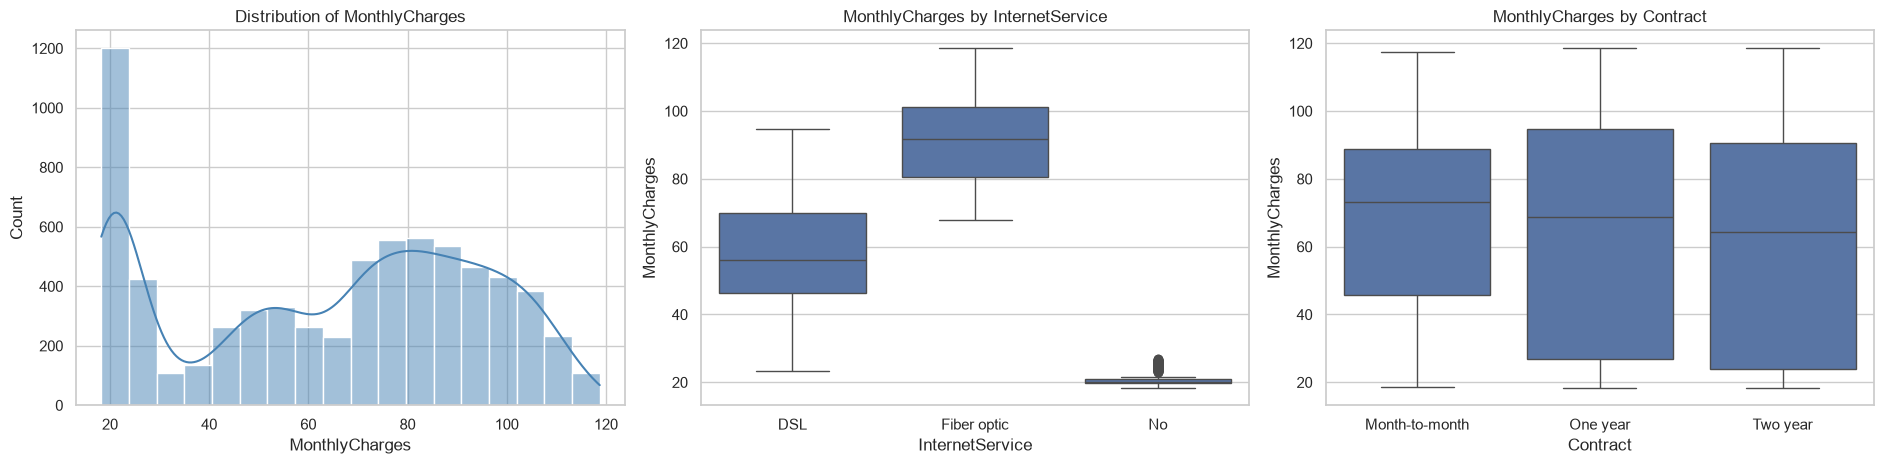

count   7,043.0000
mean       64.7617
std        30.0900
min        18.2500
25%        35.5000
50%        70.3500
75%        89.8500
max       118.7500
Name: MonthlyCharges, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of MonthlyCharges")
sns.boxplot(data=df, x="InternetService", y='MonthlyCharges', ax=axes[1])
axes[1].set_title("MonthlyCharges by InternetService")
sns.boxplot(data=df, x="Contract", y='MonthlyCharges', ax=axes[2])
axes[2].set_title("MonthlyCharges by Contract")
plt.tight_layout()
plt.show()

print(df['MonthlyCharges'].describe())

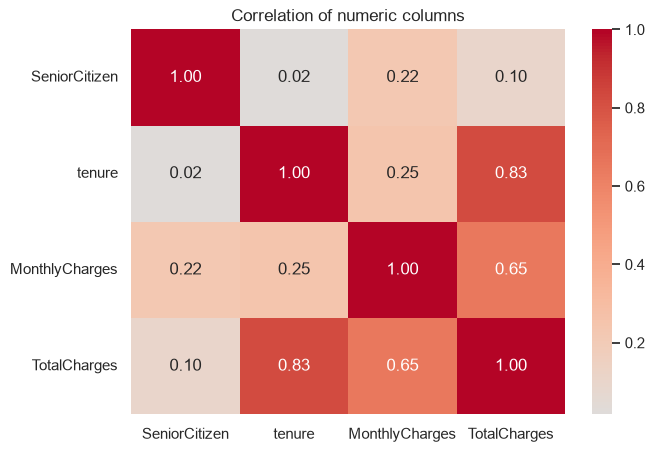

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996


In [17]:
numeric_raw = df.select_dtypes(include="number")
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_raw.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric columns")
plt.show()

# Is TotalCharges basically the target in disguise?
leak_corr = np.corrcoef(df["TotalCharges"], df["tenure"] * df["MonthlyCharges"])[0, 1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {leak_corr:.4f}")

## Feature Engineering

In [18]:
def engineer_features(data):
    d = data.copy()
    d = d.drop(columns=["customerID"], errors="ignore")
    # Harmonise duplicate labels
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
    d[addon_cols] = d[addon_cols].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    # counts
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_streaming"] = (d[["StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
    d["num_protection"] = (d[["OnlineSecurity", "OnlineBackup","DeviceProtection", "TechSupport"]] == "Yes").sum(axis=1)

    #Binary flags
    d["has_internet"] = (d["InternetService"] != "No").astype(int)
    d["is_fiber"] = (d["InternetService"] == "Fiber optic").astype(int)
    d["has_phone"] = (d["PhoneService"] == "Yes").astype(int)
    d["multiple_lines_flag"] = (d["MultipleLines"] == "Yes").astype(int)
    d["total_services"] = (d["num_addons"] + d["has_internet"]+ d["has_phone"] + d["multiple_lines_flag"])
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic", case=False).astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["has_family"] = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)

    # Tenure transformations
    d["log_tenure"] = np.log1p(d["tenure"])
    d["tenure_sq"] = d["tenure"] ** 2
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
    labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    #Leakage control
    if not False:
        d = d.drop(columns=["TotalCharges"], errors="ignore")
    return d


X_all = engineer_features(df.drop(columns=['MonthlyCharges']))
y = df['MonthlyCharges']
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,num_addons,num_streaming,num_protection,has_internet,is_fiber,has_phone,multiple_lines_flag,total_services,auto_pay,is_month_to_month,has_family,log_tenure,tenure_sq,tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,1,0,1,1,0,0,0,2,0,1,1,0.6931,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,2,0,2,1,0,1,0,4,0,0,0,3.5553,1156,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,2,0,2,1,0,1,0,4,0,1,0,1.0986,4,0-12
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,3,0,3,1,0,0,0,4,1,0,0,3.8286,2025,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,0,0,0,1,1,1,0,2,0,1,0,1.0986,4,0-12


In [19]:
new_feats = ["num_addons", "num_streaming", "num_protection", "total_services","has_internet", "is_fiber", "has_phone", "multiple_lines_flag",
"auto_pay", "is_month_to_month", "has_family", "log_tenure", "tenure_sq"]
corr_with_target = (pd.concat([X_all[new_feats], y], axis=1)
.corr()['MonthlyCharges'].drop('MonthlyCharges').sort_values(ascending=False))
corr_with_target.to_frame("corr with MonthlyCharges")

,corr with MonthlyCharges
total_services,0.8514
is_fiber,0.7871
has_internet,0.7636
num_addons,0.7247
num_streaming,0.7179
num_protection,0.5649
multiple_lines_flag,0.4904
has_phone,0.2474
log_tenure,0.2397
tenure_sq,0.2382
